    Province  Scolarisation Primaire (%)  Scolarisation Collégial (%)  \
0   Assa-Zag                       92.05                        75.43   
1    Guelmim                      101.47                        86.83   
2  Sidi Ifni                       96.81                        81.26   
3    Tan-Tan                      101.77                        85.74   

   Scolarisation Qualifiant (%)  Abandon Primaire (%)  Abandon Collégial (%)  \
0                         60.87                  0.64                   2.23   
1                         59.77                  1.20                   4.71   
2                         58.87                  0.73                   3.04   
3                         56.32                  1.03                   4.14   

   Abandon Qualifiant (%)  Région total (%)  Ratio Primaire  Ratio Collégial  \
0                    3.11              1.62              20               22   
1                    3.62              2.73              22              

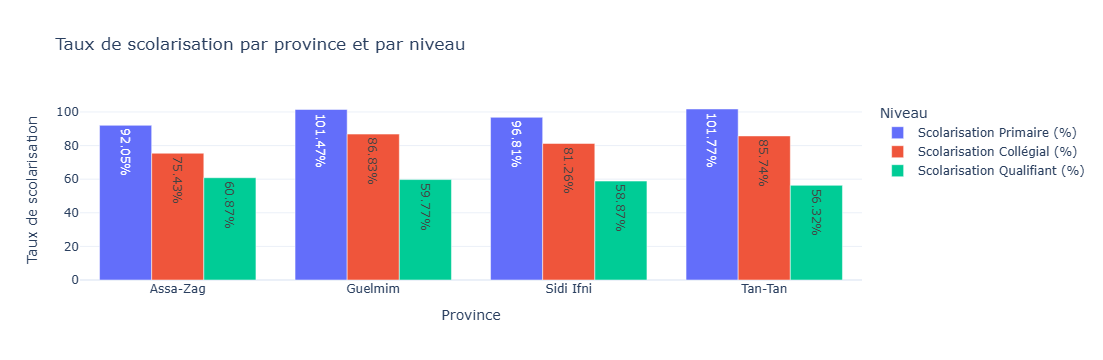

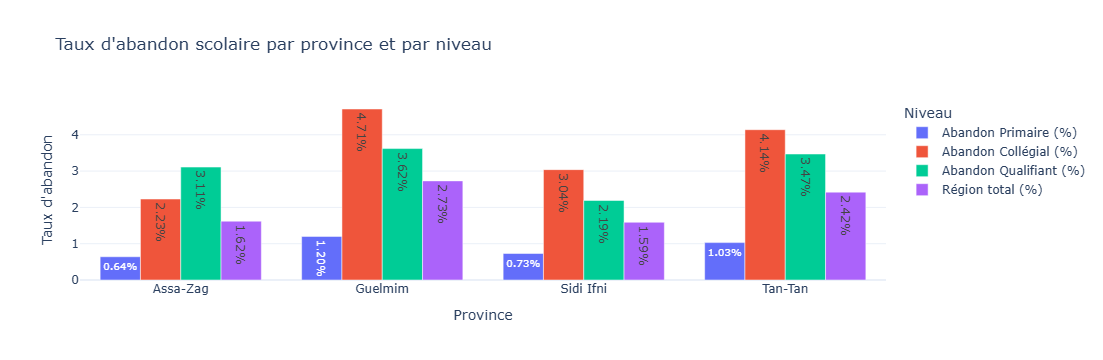

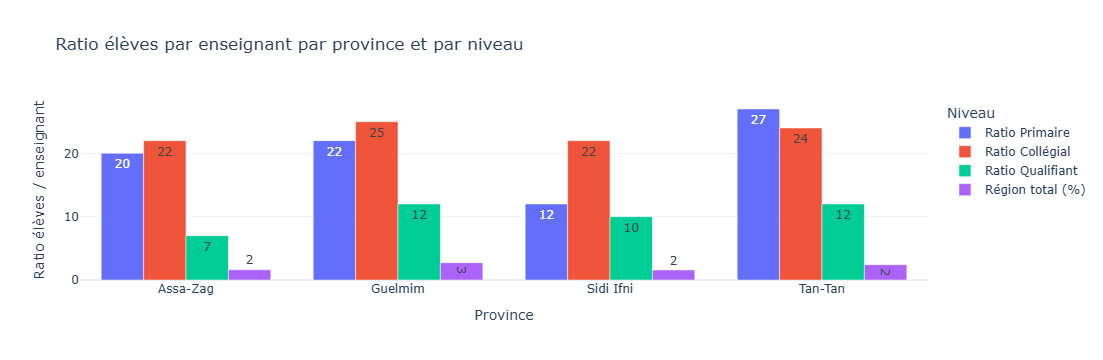


===== Analyse synthétique =====

Taux de scolarisation moyen :
Scolarisation Primaire (%)      98.0250
Scolarisation Collégial (%)     82.3150
Scolarisation Qualifiant (%)    58.9575
dtype: float64

Taux d'abandon moyen :
Abandon Primaire (%)      0.9000
Abandon Collégial (%)     3.5300
Abandon Qualifiant (%)    3.0975
Région total (%)          2.0900
dtype: float64

Ratio moyen élèves par enseignant :
Ratio Primaire      20.25
Ratio Collégial     23.25
Ratio Qualifiant    10.25
Région total (%)     2.09
dtype: float64


In [7]:
import pandas as pd
import plotly.express as px

# =========================
# 1. Chargement des données
# =========================
file_path = r"../data/Indicateurs_Education_1.csv"

df = pd.read_csv(file_path, header=1)

print(df.head())
print(df.info())

# =========================
# 2. Taux de scolarisation
# =========================
df_scolarisation = df[[
    "Province",
    "Scolarisation Primaire (%)",
    "Scolarisation Collégial (%)",
    "Scolarisation Qualifiant (%)"
]]

df_scolarisation_long = df_scolarisation.melt(
    id_vars="Province",
    var_name="Niveau",
    value_name="Taux de scolarisation"
)

fig1 = px.bar(
    df_scolarisation_long,
    x="Province",
    y="Taux de scolarisation",
    color="Niveau",
    barmode="group",
    text="Taux de scolarisation",
    title="Taux de scolarisation par province et par niveau"
)

fig1.update_traces(texttemplate="%{text:.2f}%")
fig1.update_layout(template="plotly_white")
fig1.show()

# =========================
# 3. Taux d'abandon scolaire
# =========================
df_abandon = df[[
    "Province",
    "Abandon Primaire (%)",
    "Abandon Collégial (%)",
    "Abandon Qualifiant (%)",
    "Région total (%)"
]]

df_abandon_long = df_abandon.melt(
    id_vars="Province",
    var_name="Niveau",
    value_name="Taux d'abandon"
)

fig2 = px.bar(
    df_abandon_long,
    x="Province",
    y="Taux d'abandon",
    color="Niveau",
    barmode="group",
    text="Taux d'abandon",
    title="Taux d'abandon scolaire par province et par niveau"
)

fig2.update_traces(texttemplate="%{text:.2f}%")
fig2.update_layout(template="plotly_white")
fig2.show()

# =========================
# 4. Ratio élèves par enseignant
# =========================
df_ratio = df[[
    "Province",
    "Ratio Primaire",
    "Ratio Collégial",
    "Ratio Qualifiant",
    "Région total (%)"
]]

df_ratio_long = df_ratio.melt(
    id_vars="Province",
    var_name="Niveau",
    value_name="Ratio élèves / enseignant"
)

fig3 = px.bar(
    df_ratio_long,
    x="Province",
    y="Ratio élèves / enseignant",
    color="Niveau",
    barmode="group",
    text="Ratio élèves / enseignant",
    title="Ratio élèves par enseignant par province et par niveau"
)

fig3.update_traces(texttemplate="%{text:.0f}")
fig3.update_layout(template="plotly_white")
fig3.show()

# =========================
# 5. Analyse automatique
# =========================
print("\n===== Analyse synthétique =====")

print("\nTaux de scolarisation moyen :")
print(df_scolarisation.drop(columns="Province").mean())

print("\nTaux d'abandon moyen :")
print(df_abandon.drop(columns="Province").mean())

print("\nRatio moyen élèves par enseignant :")
print(df_ratio.drop(columns="Province").mean())